In [1]:
%pip install langchain_groq  langchain_core --q

Note: you may need to restart the kernel to use updated packages.


In [13]:
import os
from dotenv import load_dotenv
load_dotenv()

from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [3]:
llm = ChatGroq(model = 'llama-3.3-70b-versatile')


In [4]:
def extract_text(content):
    if isinstance(content, str):
        return content

    if isinstance(content, list):
        return "\n".join(
            item["text"]
            for item in content
            if item.get("type") == "text"
        )

    return str(content)

In [9]:
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage

In [10]:
#Schema for structured output
class Route(BaseModel):
    step: Literal['poem', 'story', 'joke'] = Field(description="The  next step in the routing process")

# Augment the LLm with Schema for structured output
router = llm.with_structured_output(Route)

#state class
class State(TypedDict):
    input : str
    decision : str
    output : str

In [12]:
def llm_call1(state: State) -> State:
    '''Write a story'''
    result = llm.invoke(state["input"])
    print("Calling llm_call1 with input:", state["input"])

    return {"output" : extract_text(result)}

def llm_call2(state: State) -> State:
    '''Write a joke'''
    result = llm.invoke(state["input"])
    print("Calling llm_call2 with input:", state["input"])
    return {"output" : extract_text(result)}

def llm_call3(state: State) -> State:
    '''Write a poem'''
    result = llm.invoke(state["input"])
    print("Calling llm_call3 with input:", state["input"])
    return {"output" : extract_text(result)}

def llm_call_router(state: State):
    # route the input to the appropriate node

    decision = router.invoke(
        [
            SystemMessage(content = 'Route the input to story, joke or poem based on the input'),

            HumanMessage(content = state["input"])
            ]
        )
    return {"decision" : decision.step}

In [15]:
def route_decicion(state: State):
    #route the decision to the appropriate node
    if state["decision"] == "story":
        return llm_call1(state)
    elif state["decision"] == "joke":
        return llm_call2(state)
    elif state["decision"] == "poem":
        return llm_call3(state)
    else:
        raise ValueError(f"Invalid decision: {state['decision']}")

In [22]:
def route_decicion(state: State):
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"
    else:
        raise ValueError(f"Invalid decision: {state['decision']}")

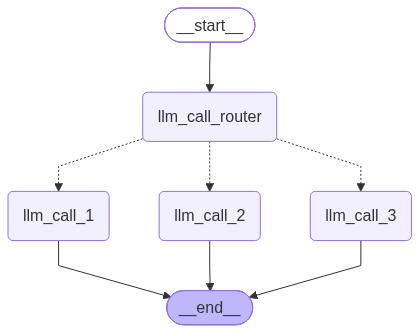

In [23]:
router_builder = StateGraph(State)
router_builder.add_node("llm_call_1", llm_call1)
router_builder.add_node("llm_call_2", llm_call2)
router_builder.add_node("llm_call_3", llm_call3)
router_builder.add_node("llm_call_router", llm_call_router)

router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges('llm_call_router', route_decicion,
                                      { 'llm_call_1': "llm_call_1",
                                        'llm_call_2': "llm_call_2",
                                        'llm_call_3': "llm_call_3"
                                      },)

router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

route_workflow = router_builder.compile()
graph_image = route_workflow.get_graph().draw_mermaid_png()
display(Image(graph_image))


In [31]:
state = route_workflow.invoke({"input" : "Write a joke about the democracy in India"})

Calling llm_call2 with input: Write a joke about the democracy in India


In [32]:
state['output']

'content=\'Why did the democracy in India go to therapy?\\n\\nBecause it was struggling to "represent" its true self, and was feeling a little "divided"! But in the end, it just needed to "vote" for a change in perspective! (ba-dum-tss)\' additional_kwargs={} response_metadata={\'token_usage\': {\'completion_tokens\': 58, \'prompt_tokens\': 43, \'total_tokens\': 101, \'completion_time\': 0.199395202, \'completion_tokens_details\': None, \'prompt_time\': 0.001519817, \'prompt_tokens_details\': None, \'queue_time\': 0.169847372, \'total_time\': 0.200915019}, \'model_name\': \'llama-3.3-70b-versatile\', \'system_fingerprint\': \'fp_45180df409\', \'service_tier\': \'on_demand\', \'finish_reason\': \'stop\', \'logprobs\': None, \'model_provider\': \'groq\'} id=\'lc_run--01a000d9-12d7-7b01-9257-994297b6f14c-0\' tool_calls=[] invalid_tool_calls=[] usage_metadata={\'input_tokens\': 43, \'output_tokens\': 58, \'total_tokens\': 101}'